# Customer Churn Analysis
**Author:** Rohan | MIS Analyst — Data Analytics Portfolio  
**Tools:** Python · pandas · matplotlib · seaborn · MySQL (pymysql)  
**Dataset:** 7,000 telecom customers · 32 features  

**Objective:** Identify which customer segments have the highest churn risk, 
quantify the monthly and annual revenue impact, and surface actionable 
retention recommendations for the business.

## 1. Data loading — connecting to MySQL
Loading the cleaned dataset directly from MySQL (churndb → churn_clean table).  
Data was pre-cleaned in MySQL Workbench: column names standardized, 
blank churn_reason values filled with 'No Churn', and data types verified

## 2. Feature engineering
Creating two new grouping columns before analysis:
- `tenure_bucket` — groups customers into 4 lifecycle stages (0–12, 13–24, 25–48, 49–72 months)
- `cltv_segment` — groups customers by Customer Lifetime Value into 4 tiers
- `churned` — a filtered dataframe containing only churned customers, used for reason analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 11,
})

# Color palette
CORAL = '#D85A30'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
BLUE  = '#378ADD'
GRAY  = '#888780'
LIGHT = '#F1EFE8'

print("Setup done")

Setup done


In [4]:
import pymysql

connection = pymysql.connect(
    host='localhost',
    user='root',
    password='your Password',   # your actual password
    database='churndb'
)

df = pd.read_sql("SELECT * FROM churn_clean", connection)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 7,032
Columns: 32


,customer_id,Count,Country,State,City,zip_code,Latitude,Longitude,Gender,senior_citizen,...,Contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,CLTV,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
# Tenure buckets
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 months', '13–24 months', '25–48 months', '49–72 months']
)

# CLTV segments
df['cltv_segment'] = pd.cut(
    df['CLTV'],
    bins=[0, 2500, 4000, 5500, 7000],
    labels=['Low (<2.5K)', 'Mid (2.5–4K)', 'High (4–5.5K)', 'Very High (5.5K+)']
)

# Separate churned customers for reason analysis
churned = df[df['churn_value'] == 1].copy()

print(f"Churned  : {len(churned):,}")
print(f"Retained : {len(df) - len(churned):,}")
print(f"Churn rate: {df['churn_value'].mean()*100:.1f}%")

Churned  : 1,869
Retained : 5,163
Churn rate: 26.6%


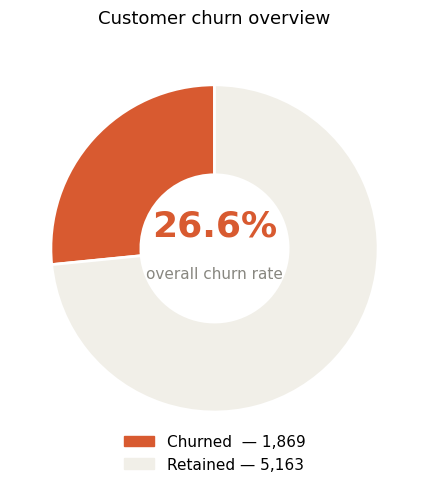

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

sizes  = [df['churn_value'].sum(), (df['churn_value'] == 0).sum()]
colors = [CORAL, LIGHT]

ax.pie(sizes, colors=colors, startangle=90,
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))

# Center text
ax.text(0,  0.08, f"{df['churn_value'].mean()*100:.1f}%",
        ha='center', fontsize=26, fontweight='bold', color=CORAL)
ax.text(0, -0.18, 'overall churn rate',
        ha='center', fontsize=11, color=GRAY)

# Legend
ax.legend(handles=[
    mpatches.Patch(color=CORAL, label=f'Churned  — {sizes[0]:,}'),
    mpatches.Patch(color=LIGHT, label=f'Retained — {sizes[1]:,}')
], loc='lower center', bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=11)

ax.set_title('Customer churn overview', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('chart1_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Overall churn rate is 26.6
Nearly 3 in 10 customers have churned — significantly above the telecom 
industry average of ~20%. This confirms churn is a critical business problem 
requiring immediate attention across multiple customer segments.

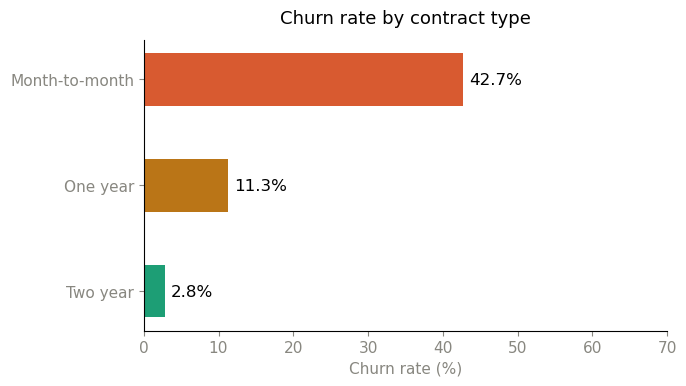

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ct = df.groupby('Contract')['churn_value'].mean() * 100
ct = ct.sort_values(ascending=True)

bars = ax.barh(ct.index, ct.values,
               color=[TEAL, AMBER, CORAL], height=0.5, edgecolor='none')

for bar, val in zip(bars, ct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=12)

ax.set_xlim(0, 70)
ax.set_xlabel('Churn rate (%)', color=GRAY)
ax.tick_params(colors=GRAY)
ax.set_title('Churn rate by contract type', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('chart2_contract.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Contract type is the #1 churn driver
Month-to-month customers churn at **42.7%** compared to just **2.8%** for 
two-year contract holders — a 15× difference.  

This is the single strongest predictor of churn in the entire dataset. 
The business should prioritize converting month-to-month customers to 
longer contracts, especially in their first 6 months.

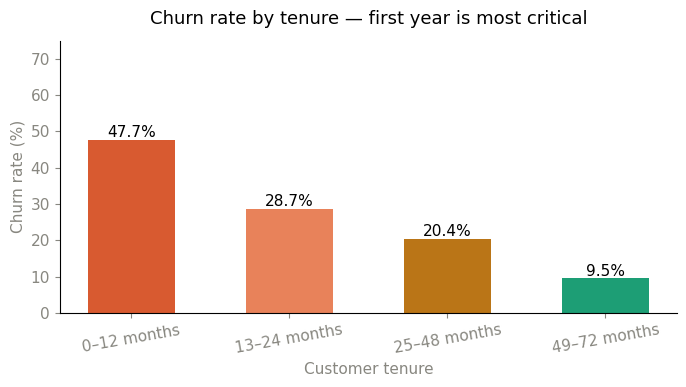

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

tb = df.groupby('tenure_bucket', observed=True)['churn_value'].mean() * 100

bars = ax.bar(tb.index, tb.values,
              color=[CORAL, '#E8825A', AMBER, TEAL],
              width=0.55, edgecolor='none')

for bar, val in zip(bars, tb.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f'{val:.1f}%', ha='center', fontsize=11)

ax.set_ylim(0, 75)
ax.set_ylabel('Churn rate (%)', color=GRAY)
ax.set_xlabel('Customer tenure', color=GRAY)
ax.tick_params(axis='x', rotation=10)
ax.tick_params(colors=GRAY)
ax.set_title('Churn rate by tenure — first year is most critical', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('chart3_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — First-year customers are the highest-risk group
Customers in their first 12 months churn at **47.7%**. After 24 months 
churn drops to 20.4%, and after 48 months to just 9.5%.  

This steep decline shows that if the business can retain a customer 
through their first year, long-term retention becomes significantly easier. 
The problem is onboarding and early engagement — not the product itself.

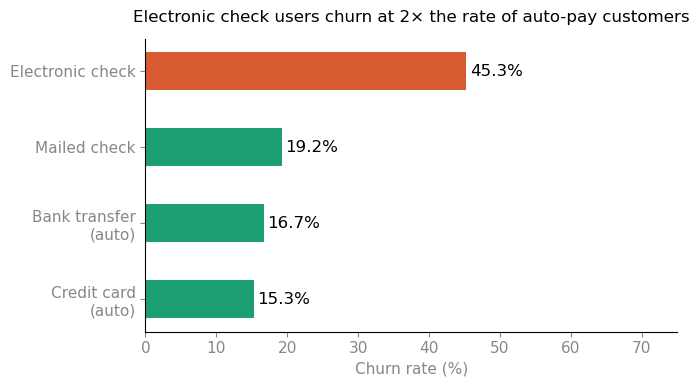

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

pm = df.groupby('payment_method')['churn_value'].mean() * 100
pm = pm.sort_values(ascending=True)

# Color bars by risk level
bar_colors = [TEAL if v < 30 else AMBER if v < 45 else CORAL for v in pm.values]

# Shorten label names for display
short_labels = [m.replace(' (automatic)', '\n(auto)') for m in pm.index]

bars = ax.barh(short_labels, pm.values,
               color=bar_colors, height=0.5, edgecolor='none')

for bar, val in zip(bars, pm.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=12)

ax.set_xlim(0, 75)
ax.set_xlabel('Churn rate (%)', color=GRAY)
ax.tick_params(colors=GRAY)
ax.set_title('Electronic check users churn at 2× the rate of auto-pay customers',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('chart4_payment.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Electronic check users churn at 2× the rate of auto-pay customers
Electronic check users churn at **45.3%** vs 15-16% for auto-pay methods.  

This is a behavioral signal — customers who set up automatic payments 
have a higher psychological commitment to the service. A simple auto-pay 
enrollment nudge at the 3-month mark (with a small bill credit as incentive) 
could meaningfully reduce churn in this segment.

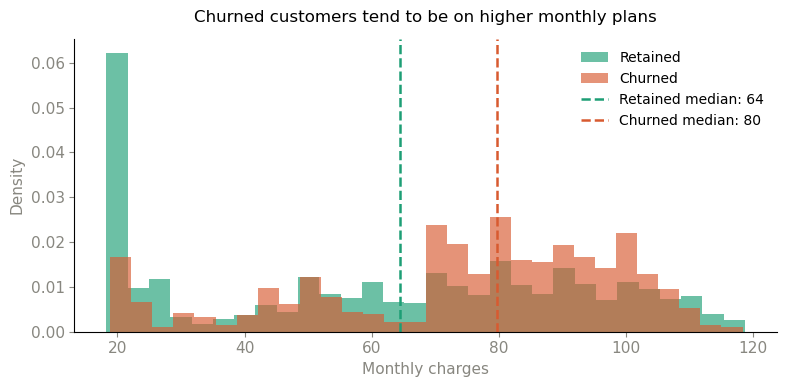

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

retained_mc = df[df['churn_value'] == 0]['monthly_charges']
churned_mc  = df[df['churn_value'] == 1]['monthly_charges']

ax.hist(retained_mc, bins=30, alpha=0.65, color=TEAL,
        label='Retained', density=True)
ax.hist(churned_mc,  bins=30, alpha=0.65, color=CORAL,
        label='Churned',  density=True)

ax.axvline(retained_mc.median(), color=TEAL, linestyle='--', linewidth=1.8,
           label=f'Retained median: {retained_mc.median():.0f}')
ax.axvline(churned_mc.median(),  color=CORAL, linestyle='--', linewidth=1.8,
           label=f'Churned median: {churned_mc.median():.0f}')

ax.set_xlabel('Monthly charges', color=GRAY)
ax.set_ylabel('Density', color=GRAY)
ax.tick_params(colors=GRAY)
ax.legend(frameon=False, fontsize=10)
ax.set_title('Churned customers tend to be on higher monthly plans',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('chart5_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Churned customers tend to be on higher monthly plans
The distribution shows churned customers have a higher median monthly charge 
compared to retained customers.  

This indicates a **price vs. perceived value** problem — customers paying 
more are leaving more, suggesting the premium plans are not delivering 
sufficient perceived value to justify the cost.

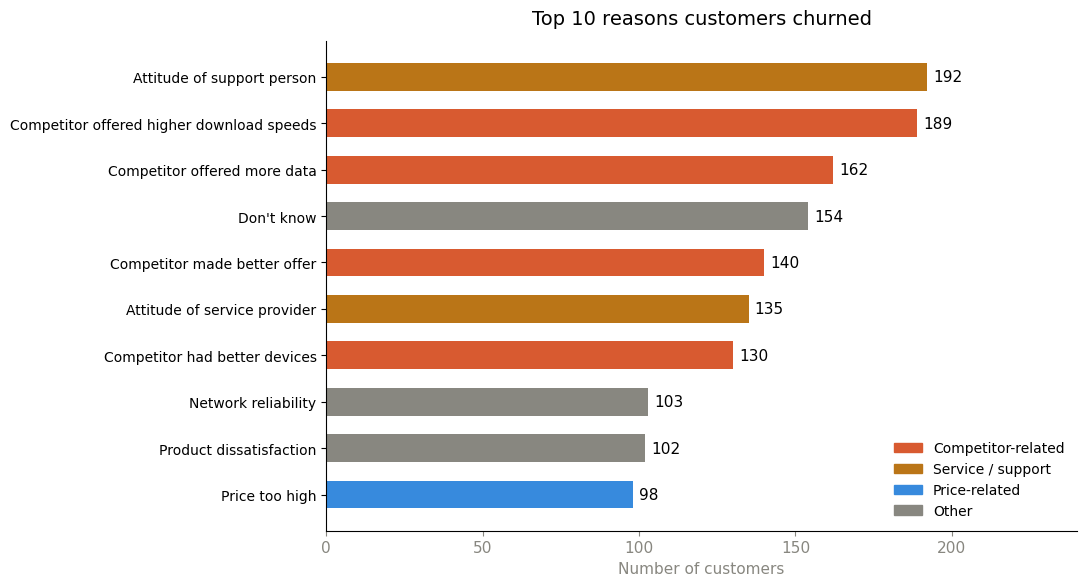

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

reason_counts = churned['churn_reason'].value_counts().head(10)

# Color each bar by category
def reason_color(r):
    r = r.lower()
    if 'competitor' in r:                        return CORAL
    if 'attitude' in r or 'support' in r:        return AMBER
    if 'price' in r or 'charge' in r:            return BLUE
    return GRAY

colors_r = [reason_color(r) for r in reason_counts.index]

# Plot in reverse so highest bar is at top
bars = ax.barh(reason_counts.index[::-1],
               reason_counts.values[::-1],
               color=colors_r[::-1], height=0.6, edgecolor='none')

for bar, val in zip(bars, reason_counts.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=11)

ax.set_xlabel('Number of customers', color=GRAY)
ax.set_xlim(0, 240)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', colors=GRAY)

ax.legend(handles=[
    mpatches.Patch(color=CORAL, label='Competitor-related'),
    mpatches.Patch(color=AMBER, label='Service / support'),
    mpatches.Patch(color=BLUE,  label='Price-related'),
    mpatches.Patch(color=GRAY,  label='Other'),
], loc='lower right', frameon=False, fontsize=10)

ax.set_title('Top 10 reasons customers churned', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('chart6_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Service quality is driving more churn than competitor gaps
The single biggest churn reason is **attitude of support person (192 customers)** 
— ahead of every individual competitor-related reason.  

Combined service and support issues account for ~35% of all churns.  
This is significant because it means investing in support team training 
will deliver higher retention ROI than product feature development in 
the short term.  

> This insight is only possible because this dataset includes a `churn_reason` 
column — making this analysis uniquely actionable compared to standard 
churn datasets.

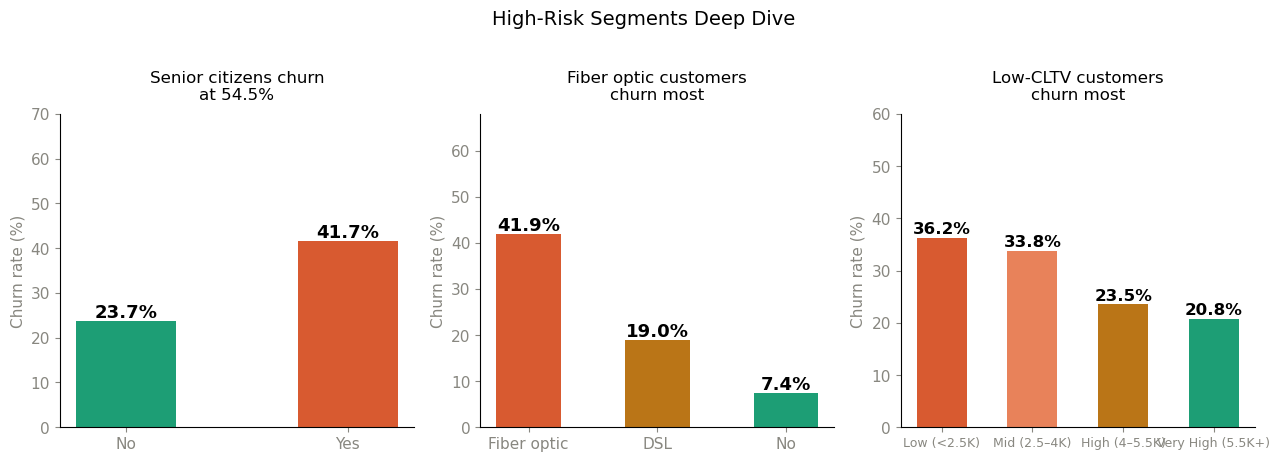

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('High-Risk Segments Deep Dive', fontsize=14, fontweight='normal', y=1.02)

# --- Senior citizen ---
ax = axes[0]
sc = df.groupby('senior_citizen')['churn_value'].mean() * 100
bars = ax.bar(sc.index, sc.values,
              color=[TEAL, CORAL], width=0.45, edgecolor='none')
for bar, val in zip(bars, sc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 70)
ax.set_ylabel('Churn rate (%)', color=GRAY)
ax.tick_params(colors=GRAY)
ax.set_title('Senior citizens churn\nat 54.5%', fontsize=12, pad=10)

# --- Internet service ---
ax = axes[1]
inet = df.groupby('internet_service')['churn_value'].mean() * 100
inet = inet.sort_values(ascending=False)
bars = ax.bar(inet.index, inet.values,
              color=[CORAL, AMBER, TEAL], width=0.5, edgecolor='none')
for bar, val in zip(bars, inet.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 68)
ax.set_ylabel('Churn rate (%)', color=GRAY)
ax.tick_params(colors=GRAY)
ax.set_title('Fiber optic customers\nchurn most', fontsize=12, pad=10)

# --- CLTV segment ---
ax = axes[2]
cltv = df.groupby('cltv_segment', observed=True)['churn_value'].mean() * 100
bars = ax.bar(cltv.index, cltv.values,
              color=[CORAL, '#E8825A', AMBER, TEAL],
              width=0.55, edgecolor='none')
for bar, val in zip(bars, cltv.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 60)
ax.set_ylabel('Churn rate (%)', color=GRAY)
ax.tick_params(axis='x', labelsize=9, colors=GRAY)
ax.tick_params(axis='y', colors=GRAY)
ax.set_title('Low-CLTV customers\nchurn most', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('chart7_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Senior citizens and fiber optic customers are disproportionately high-risk
- Senior citizens churn at **41.7%** vs 23.7% for non-seniors
- Fiber optic customers churn at **41.9%** despite being on a premium service

The fiber optic finding is counterintuitive — customers on the best service 
are leaving the most. This points to a pricing and value communication problem, 
not a product problem. Senior citizens likely need simplified plans and 
dedicated support rather than standard retention approaches.

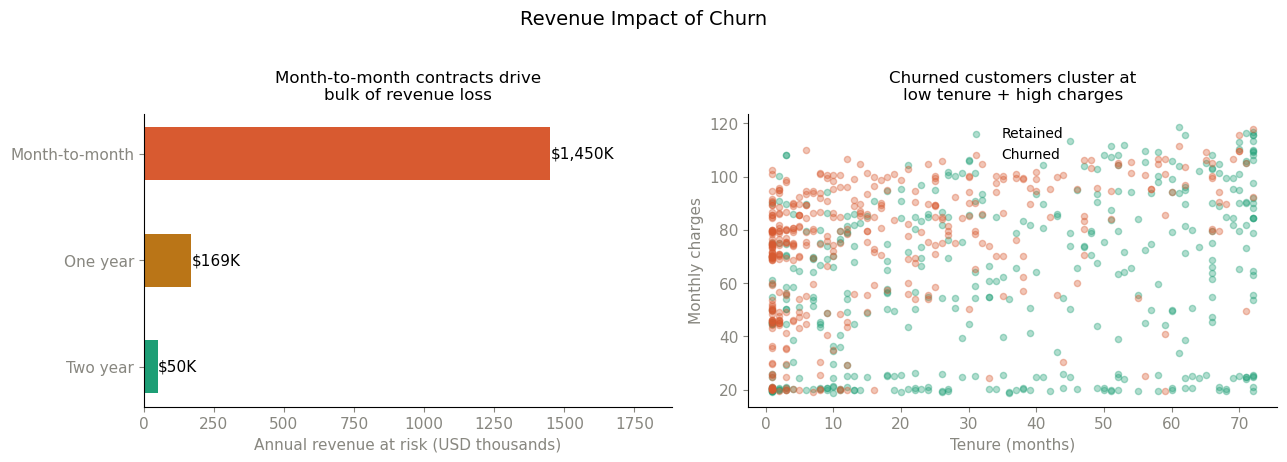

Monthly revenue lost    : $139,131
Annualized revenue lost : $1,669,570


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Revenue Impact of Churn', fontsize=14, fontweight='normal', y=1.02)

# --- Annual revenue at risk by contract ---
ax = axes[0]
rev = (df[df['churn_value'] == 1]
       .groupby('Contract')['monthly_charges']
       .sum() * 12 / 1000)
rev = rev.sort_values(ascending=True)

bars = ax.barh(rev.index, rev.values,
               color=[TEAL, AMBER, CORAL], height=0.5, edgecolor='none')
for bar, val in zip(bars, rev.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}K', va='center', fontsize=11)

ax.set_xlabel('Annual revenue at risk (USD thousands)', color=GRAY)
ax.set_xlim(0, max(rev.values) * 1.3)
ax.tick_params(colors=GRAY)
ax.set_title('Month-to-month contracts drive\nbulk of revenue loss', fontsize=12, pad=10)

# --- Scatter: tenure vs monthly charges ---
ax = axes[1]
ret_sample = df[df['churn_value'] == 0].sample(400, random_state=42)
chu_sample = df[df['churn_value'] == 1].sample(400, random_state=42)

ax.scatter(ret_sample['tenure_months'], ret_sample['monthly_charges'],
           alpha=0.35, color=TEAL, s=20, label='Retained')
ax.scatter(chu_sample['tenure_months'], chu_sample['monthly_charges'],
           alpha=0.35, color=CORAL, s=20, label='Churned')

ax.set_xlabel('Tenure (months)', color=GRAY)
ax.set_ylabel('Monthly charges', color=GRAY)
ax.tick_params(colors=GRAY)
ax.legend(frameon=False, fontsize=10)
ax.set_title('Churned customers cluster at\nlow tenure + high charges', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('chart8_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# Revenue summary printout
total_monthly = df[df['churn_value'] == 1]['monthly_charges'].sum()
print(f"Monthly revenue lost    : ${total_monthly:,.0f}")
print(f"Annualized revenue lost : ${total_monthly * 12:,.0f}")

### Finding — Revenue loss is heavily concentrated in month-to-month contracts
The scatter chart confirms that churned customers (red) cluster in the 
**top-left zone** — low tenure combined with high monthly charges.  

This means the business is losing its newest and highest-paying customers first.  

**Revenue summary:**
- Monthly revenue lost to churn: ~$139K
- Annualized revenue at risk: ~$1.67M  

Converting just 20% of high-risk month-to-month customers to annual contracts 
would save an estimated $260K+ per year.

---

## Summary — Business recommendations

| # | Finding | Recommendation | Est. impact |
|---|---|---|---|
| 1 | Month-to-month churn at 42.7% | Offer discount to switch to annual in first 6 months | High |
| 2 | First-year churn at 11.3% | Structured 90-day onboarding program | High |
| 3 | Support attitude = #1 churn reason | Support quality scoring + targeted training | High |
| 4 | Electronic check churn at 45.3% | Auto-pay nudge at month 3 with bill credit | Medium |
| 5 | Senior citizens churn at 41.7% | Dedicated senior support tier + simplified plans | Medium |

---

*Tools: Python · pandas · matplotlib · seaborn · MySQL*  
*Dataset: 7,000 telecom customers · 32 features*  
*Project by: Rohan — Data Analytics Portfolio*